# Nanobody Report Analysis
Load the pipeline output and inspect score distributions.

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

report_path = Path('..') / 'results' / 'report.csv'
df = pd.read_csv(report_path)
df.head()

,rank,sequence_id,length,hydrophobicity,net_charge,charge_balance,molecular_weight,freq_A,freq_C,freq_D,...,backend,confidence,stability,plddt_mean,notes,backend_requested,backend_used,pdb_file,hydrophobicity_norm,developability_score
0,1,nb_002,116,-0.338793,1.0,0.50,12445.5994,0.103448,0.017241,0.034483,...,esmfold,0.0086,0.0086,0.86,Real ESMFold inference via ESM Atlas API.,esmfold,esmfold,data/pdb/nb_002.pdb,0.462356,0.292147
1,2,nb_003,116,-0.218966,3.0,0.25,12436.6770,0.112069,0.017241,0.025862,...,esmfold,0.0088,0.0088,0.88,Real ESMFold inference via ESM Atlas API.,esmfold,esmfold,data/pdb/nb_003.pdb,0.475670,0.221221
2,3,nb_001,116,-0.264655,3.0,0.25,12479.7017,0.103448,0.017241,0.025862,...,esmfold,0.0089,0.0089,0.89,Real ESMFold inference via ESM Atlas API.,esmfold,esmfold,data/pdb/nb_001.pdb,0.470594,0.219738


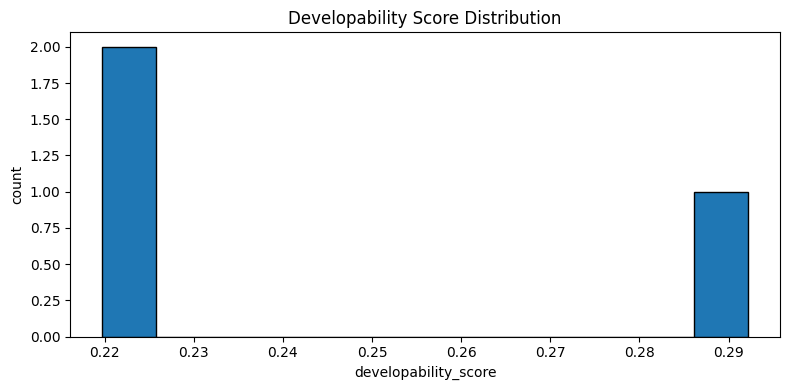

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['developability_score'], bins=12, edgecolor='black')
ax.set_title('Developability Score Distribution')
ax.set_xlabel('developability_score')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

In [21]:
df[['sequence_id', 'rank', 'developability_score']].sort_values('rank').head(10)

,sequence_id,rank,developability_score
0,nb_002,1,0.292147
1,nb_003,2,0.221221
2,nb_001,3,0.219738


## Multiple Sequence Alignment (MSA)
Load and inspect the optional alignment output (`data/msa.fasta`). If MSA was suppressed (`run_msa=false`), this cell reports that the file is absent.

MSA sequences: 3 | alignment length: 116


,sequence_id,aligned_sequence
0,nb_001,QVQLVESGGGLVQAGGSLRLSCAASGFTFSSYAMGWFRQAPGKERE...
1,nb_002,EVQLVESGGGLVQAGGSLRLSCAASGRTFSTYAMGWFRQAPGKERE...
2,nb_003,QVQLVESGGGLVQAGGSLRLSCAASGFTFSSYAMGWFRQAPGKERE...


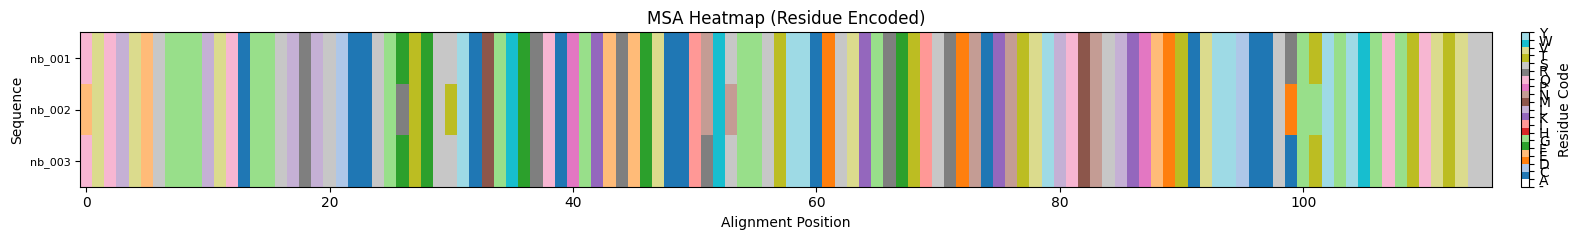

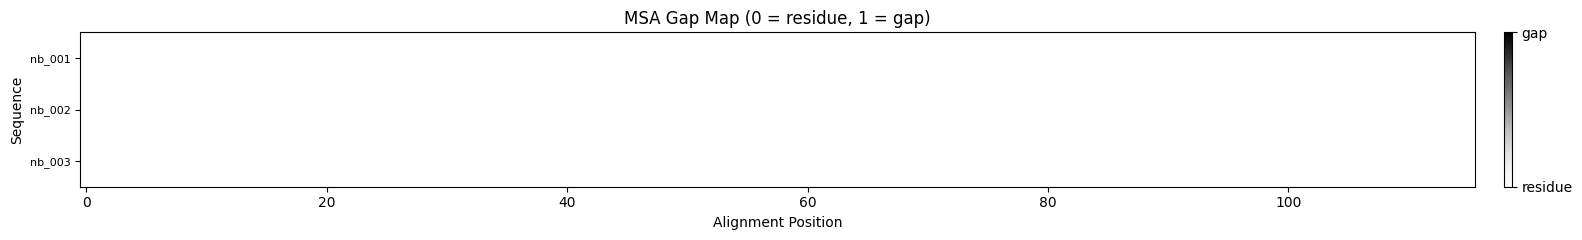

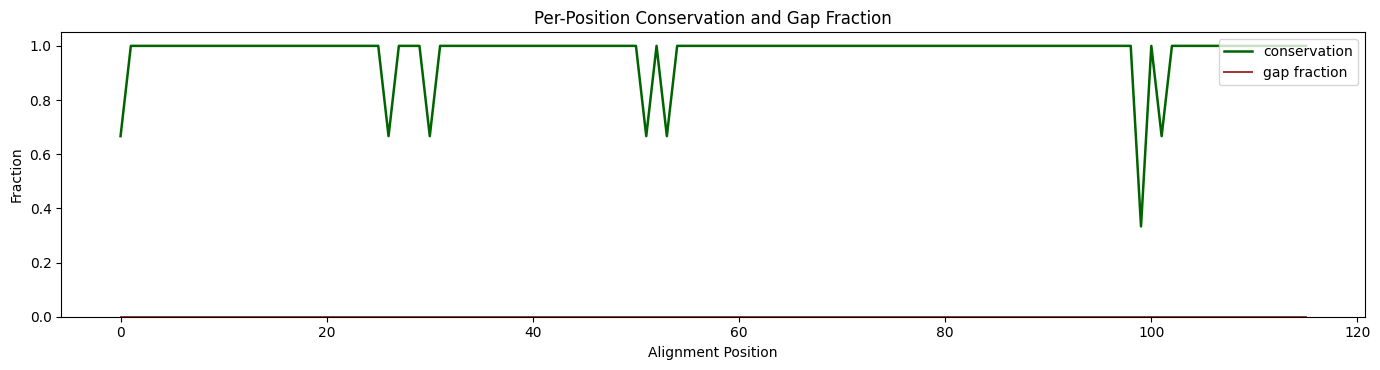

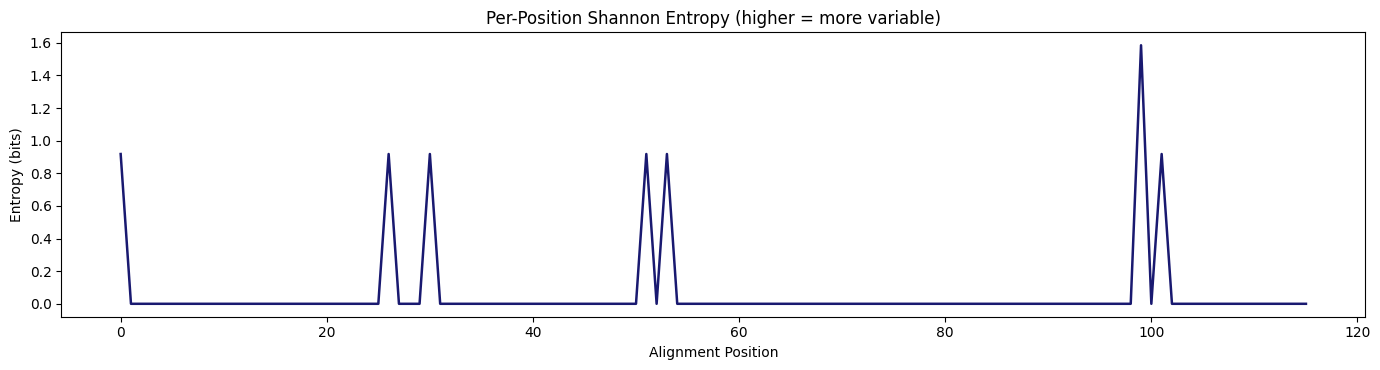

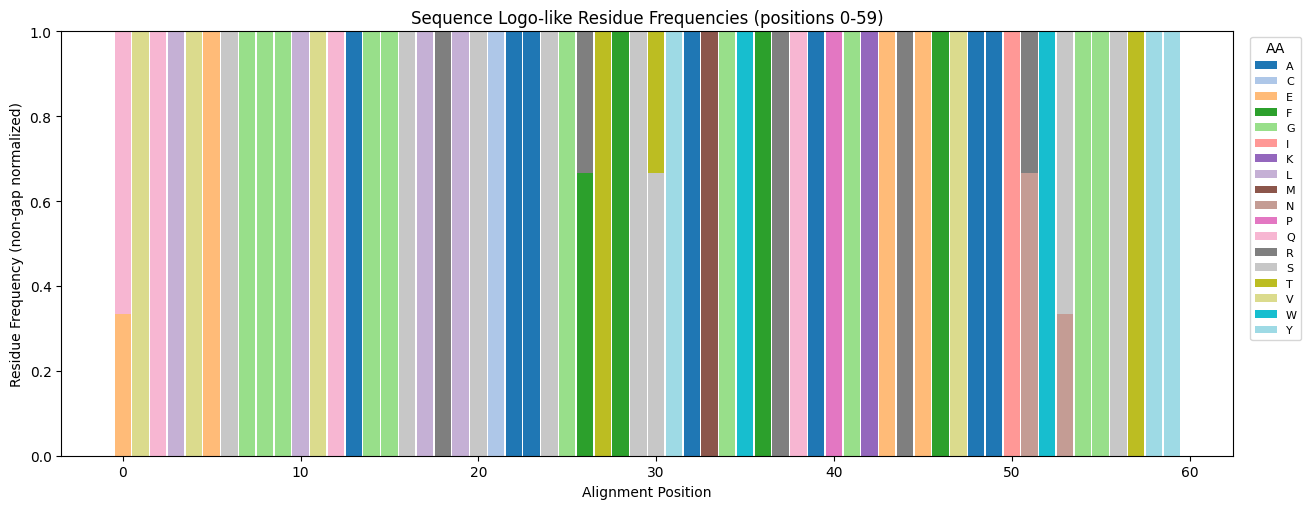

,position,conservation,gap_fraction,shannon_entropy
99,99,0.333333,0.0,1.584963
0,0,0.666667,0.0,0.918296
30,30,0.666667,0.0,0.918296
51,51,0.666667,0.0,0.918296
53,53,0.666667,0.0,0.918296
101,101,0.666667,0.0,0.918296
26,26,0.666667,0.0,0.918296
4,4,1.000000,0.0,-0.000000
8,8,1.000000,0.0,-0.000000
5,5,1.000000,0.0,-0.000000


In [22]:
from pathlib import Path

from Bio import AlignIO
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

msa_path = Path('..') / 'data' / 'msa.fasta'

if not msa_path.exists():
    print('MSA file not found. Run with --config run_msa=true (default) to generate data/msa.fasta.')
else:
    msa = AlignIO.read(msa_path, 'fasta')
    print(f'MSA sequences: {len(msa)} | alignment length: {msa.get_alignment_length()}')

    sequence_ids = [record.id for record in msa]
    aligned_sequences = [str(record.seq) for record in msa]
    n_sequences = len(aligned_sequences)
    alignment_length = len(aligned_sequences[0])

    msa_df = pd.DataFrame(
        {
            'sequence_id': sequence_ids,
            'aligned_sequence': aligned_sequences,
        }
    )
    display(msa_df)

    alphabet = '-ACDEFGHIKLMNPQRSTVWY'
    aa_to_int = {aa: idx for idx, aa in enumerate(alphabet)}
    msa_matrix = np.array(
        [[aa_to_int.get(aa, 0) for aa in sequence] for sequence in aligned_sequences],
        dtype=int,
    )

    fig_width = min(16, max(8, alignment_length * 0.15))
    fig_height = min(12, max(2.5, n_sequences * 0.45))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    im = ax.imshow(msa_matrix, aspect='auto', interpolation='nearest', cmap='tab20')
    ax.set_title('MSA Heatmap (Residue Encoded)')
    ax.set_xlabel('Alignment Position')
    ax.set_ylabel('Sequence')
    ax.set_yticks(range(n_sequences))
    ax.set_yticklabels(sequence_ids, fontsize=8)
    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label('Residue Code')
    cbar.set_ticks(range(len(alphabet)))
    cbar.set_ticklabels(list(alphabet))
    plt.tight_layout()
    plt.show()

    gap_matrix = np.array(
        [[1 if aa == '-' else 0 for aa in sequence] for sequence in aligned_sequences],
        dtype=int,
    )
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    gap_im = ax.imshow(gap_matrix, aspect='auto', interpolation='nearest', cmap='Greys', vmin=0, vmax=1)
    ax.set_title('MSA Gap Map (0 = residue, 1 = gap)')
    ax.set_xlabel('Alignment Position')
    ax.set_ylabel('Sequence')
    ax.set_yticks(range(n_sequences))
    ax.set_yticklabels(sequence_ids, fontsize=8)
    gap_cbar = plt.colorbar(gap_im, ax=ax, fraction=0.025, pad=0.02)
    gap_cbar.set_ticks([0, 1])
    gap_cbar.set_ticklabels(['residue', 'gap'])
    plt.tight_layout()
    plt.show()

    aligned_array = np.array([list(sequence) for sequence in aligned_sequences])
    conservation = []
    gap_fraction = []
    entropy = []
    for pos in range(alignment_length):
        column = aligned_array[:, pos]
        nongap = column[column != '-']
        gap_fraction.append(float((column == '-').sum() / n_sequences))

        if nongap.size == 0:
            conservation.append(0.0)
            entropy.append(0.0)
        else:
            counts = pd.Series(nongap).value_counts()
            probs = (counts / counts.sum()).to_numpy(dtype=float)
            conservation.append(float(probs.max()))
            entropy.append(float(-(probs * np.log2(probs)).sum()))

    positions = np.arange(alignment_length)
    fig, ax = plt.subplots(figsize=(min(16, max(8, alignment_length * 0.12)), 3.8))
    ax.plot(positions, conservation, color='darkgreen', linewidth=1.8, label='conservation')
    ax.plot(positions, gap_fraction, color='darkred', linewidth=1.4, alpha=0.8, label='gap fraction')
    ax.set_ylim(0, 1.05)
    ax.set_title('Per-Position Conservation and Gap Fraction')
    ax.set_xlabel('Alignment Position')
    ax.set_ylabel('Fraction')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(min(16, max(8, alignment_length * 0.12)), 3.8))
    ax.plot(positions, entropy, color='midnightblue', linewidth=1.8)
    ax.set_title('Per-Position Shannon Entropy (higher = more variable)')
    ax.set_xlabel('Alignment Position')
    ax.set_ylabel('Entropy (bits)')
    plt.tight_layout()
    plt.show()

    residues = list('ACDEFGHIKLMNPQRSTVWY')
    max_logo_positions = min(60, alignment_length)
    logo_positions = np.arange(max_logo_positions)
    frequency_by_residue = {aa: np.zeros(max_logo_positions, dtype=float) for aa in residues}

    for pos in range(max_logo_positions):
        column = aligned_array[:, pos]
        nongap = column[column != '-']
        if nongap.size == 0:
            continue
        counts = pd.Series(nongap).value_counts()
        for aa in residues:
            frequency_by_residue[aa][pos] = counts.get(aa, 0) / nongap.size

    fig, ax = plt.subplots(figsize=(min(20, max(10, max_logo_positions * 0.22)), 5.2))
    bottom = np.zeros(max_logo_positions, dtype=float)
    color_map = plt.cm.tab20(np.linspace(0, 1, len(residues)))

    for idx, aa in enumerate(residues):
        values = frequency_by_residue[aa]
        if np.any(values > 0):
            ax.bar(logo_positions, values, bottom=bottom, width=0.92, color=color_map[idx], label=aa)
            bottom += values

    ax.set_ylim(0, 1.0)
    ax.set_title(f'Sequence Logo-like Residue Frequencies (positions 0-{max_logo_positions - 1})')
    ax.set_xlabel('Alignment Position')
    ax.set_ylabel('Residue Frequency (non-gap normalized)')
    ax.legend(title='AA', bbox_to_anchor=(1.01, 1), loc='upper left', ncol=1, fontsize=8)
    plt.tight_layout()
    plt.show()

    variability_df = pd.DataFrame(
        {
            'position': positions,
            'conservation': conservation,
            'gap_fraction': gap_fraction,
            'shannon_entropy': entropy,
        }
    ).sort_values('shannon_entropy', ascending=False)
    display(variability_df.head(15))

## MSA Summary Metrics
Inspect per-sequence alignment statistics generated in `data/msa_summary.csv`.

In [23]:
msa_summary_path = Path('..') / 'data' / 'msa_summary.csv'

if not msa_summary_path.exists():
    print('MSA summary not found. Run with --config run_msa=true (default).')
else:
    msa_summary_df = pd.read_csv(msa_summary_path)
    display(msa_summary_df.sort_values('consensus_identity', ascending=False))

,sequence_id,alignment_length,nongap_length,gap_count,gap_fraction,consensus_identity
0,nb_001,116,116,0,0.0,1.000000
2,nb_003,116,116,0,0.0,0.982759
1,nb_002,116,116,0,0.0,0.948276


## Best Developability Structure Viewer
Select the highest-developability sequence from `results/report.csv`, print its sequence ID and score, and render the corresponding PDB structure interactively.

In [24]:
from pathlib import Path

from Bio import AlignIO
from IPython.display import Markdown, display
import numpy as np
import pandas as pd

report_path = Path('..') / 'results' / 'report.csv'
msa_path = Path('..') / 'data' / 'msa.fasta'
pdb_dir = Path('..') / 'data' / 'pdb'

if not report_path.exists():
    print('Report not found. Run the pipeline first to generate results/report.csv.')
elif not msa_path.exists():
    print('MSA file not found. Run with --config run_msa=true to generate data/msa.fasta.')
else:
    report_df = pd.read_csv(report_path)
    required_cols = {'sequence_id', 'developability_score', 'pdb_file'}
    if not required_cols.issubset(report_df.columns):
        missing = sorted(required_cols - set(report_df.columns))
        print(f'Report is missing required column(s): {missing}. Re-run structure + scoring with a PDB-producing backend (e.g. esmfold).')
    else:
        candidates = report_df.dropna(subset=['pdb_file']).copy()
        if candidates.empty:
            print('No pdb_file entries found in report.csv. Run with --config structure_backend=esmfold to generate PDBs.')
        else:
            best_row = candidates.sort_values('developability_score', ascending=False).iloc[0]
            best_id = str(best_row['sequence_id'])
            best_score = float(best_row['developability_score'])

            pdb_rel = Path(str(best_row['pdb_file']))
            pdb_path = pdb_rel if pdb_rel.is_absolute() else (Path('..') / pdb_rel)
            if not pdb_path.exists():
                fallback_path = pdb_dir / f'{best_id}.pdb'
                if fallback_path.exists():
                    pdb_path = fallback_path

            if not pdb_path.exists():
                print(f'PDB file for best sequence ({best_id}) was not found at {pdb_path}.')
            else:
                msa = AlignIO.read(msa_path, 'fasta')
                msa_records = {record.id: str(record.seq) for record in msa}
                if best_id not in msa_records:
                    print(f'Best sequence ID {best_id} is not present in {msa_path}.')
                else:
                    aligned_best = msa_records[best_id]
                    aligned_array = np.array([list(str(record.seq)) for record in msa])

                    variable_columns = []
                    for pos in range(aligned_array.shape[1]):
                        column = aligned_array[:, pos]
                        nongap = column[column != '-']
                        if nongap.size == 0:
                            continue
                        counts = pd.Series(nongap).value_counts()
                        max_freq = float(counts.iloc[0] / counts.sum())
                        if max_freq < 1.0:
                            variable_columns.append(pos)

                    variable_resi = []
                    residue_index = 0
                    variable_column_set = set(variable_columns)
                    for pos, aa in enumerate(aligned_best):
                        if aa != '-':
                            residue_index += 1
                            if pos in variable_column_set:
                                variable_resi.append(residue_index)

                    print(f'Best developability sequence ID: {best_id}')
                    print(f'Developability score: {best_score:.4f}')
                    print(f'PDB file: {pdb_path}')
                    print(f'Variable MSA columns (not 100% conserved): {len(variable_columns)}')
                    print(f'Highlighted sidechains in this structure: {len(variable_resi)} residue(s)')

                    pdb_text = pdb_path.read_text(encoding='utf-8', errors='ignore')

                    # Collect exact sidechain atom serials for variable residues.
                    # This avoids ambiguous viewer selection syntax and guarantees visibility.
                    backbone_atoms = {'N', 'CA', 'C', 'O', 'OXT'}
                    variable_resi_set = set(variable_resi)
                    sidechain_serials: list[int] = []
                    resi_to_resn: dict[int, str] = {}
                    for line in pdb_text.splitlines():
                        if not line.startswith(('ATOM', 'HETATM')):
                            continue
                        atom_name = line[12:16].strip()
                        resn = line[17:20].strip()
                        resi_str = line[22:26].strip()
                        serial_str = line[6:11].strip()
                        if not resi_str or not serial_str:
                            continue
                        try:
                            resi_num = int(resi_str)
                            serial_num = int(serial_str)
                        except ValueError:
                            continue

                        if resi_num in variable_resi_set and resn:
                            resi_to_resn.setdefault(resi_num, resn)

                        if resi_num in variable_resi_set and atom_name not in backbone_atoms:
                            sidechain_serials.append(serial_num)

                    if variable_resi:
                        variable_labels = [f"{resi_to_resn.get(resi, 'UNK')}{resi}" for resi in variable_resi]
                        print('Variable residues (3-letter + position): ' + ', '.join(variable_labels))

                    try:
                        import py3Dmol
                    except ImportError:
                        print('py3Dmol is not installed. Install it with: pip install py3Dmol')
                    else:
                        viewer = py3Dmol.view(width=980, height=620)
                        viewer.addModel(pdb_text, 'pdb')

                        # Restore colorful backbone style.
                        viewer.setStyle({'cartoon': {'color': 'spectrum'}})

                        if sidechain_serials:
                            viewer.addStyle(
                                {'serial': sidechain_serials},
                                {
                                    'sphere': {
                                        'radius': 1.05,
                                        'colorscheme': 'Jmol',
                                    }
                                },
                            )
                        else:
                            print('No sidechain atoms matched variable positions in this structure.')

                        viewer.setBackgroundColor('white')
                        viewer.zoomTo()
                        viewer.show()

                    """
                    preview_lines = pdb_text.splitlines()[:25]
                    display(Markdown('```\n' + '\n'.join(preview_lines) + '\n```'))
                    """

Best developability sequence ID: nb_002
Developability score: 0.2921
PDB file: ..\data\pdb\nb_002.pdb
Variable MSA columns (not 100% conserved): 7
Highlighted sidechains in this structure: 7 residue(s)
Variable residues (3-letter + position): GLU1, ARG27, THR31, ASN52, ASN54, ASP100, GLY102


3Dmol.js failed to load for some reason. Please check your browser console for error messages.